In [1]:
import numpy as np
import matplotlib.pyplot as plt

from edibles.utils.local_continuum_spline import *

from edibles.utils.final_voigt_profile import *
from edibles.utils.final_fitter import *

from edibles.utils.edibles_oracle import EdiblesOracle
from edibles.utils.edibles_spectrum import EdiblesSpectrum 
## in the earlier codes these 2 lines were not needed as this ipynb file used to sit inside the edibles/utils/ folder.


from IPython.display import display, Math

from scipy.interpolate import CubicSpline

# Na I

/Users/ayansahoo/Desktop/MITACS_2024_Canada/edibles/DR4
***Common Objects***
['HD 80558']
**Filtered File List**
27046    /HD80558/BLUE_346/HD80558_w346_n20_20150603_B....
27048    /HD80558/BLUE_346/HD80558_w346_blue_20160221_O...
27049    /HD80558/BLUE_346/HD80558_w346_blue_20150603_O...
27063    /HD80558/BLUE_346/HD80558_w346_blue_20150603_O...
27067    /HD80558/BLUE_346/HD80558_w346_blue_20160221_O...
27101    /HD80558/BLUE_346/HD80558_w346_n7_20160221_B.fits
Name: Filename, dtype: object
6
***Common Objects***
['HD 80558']
**Filtered File List**
27046    /HD80558/BLUE_346/HD80558_w346_n20_20150603_B....
27101    /HD80558/BLUE_346/HD80558_w346_n7_20160221_B.fits
Name: Filename, dtype: object
2


/var/folders/82/4_zfr0ld1js5_5zv4y2mzvs00000gn/T/ipykernel_38691/3323347300.py:87: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


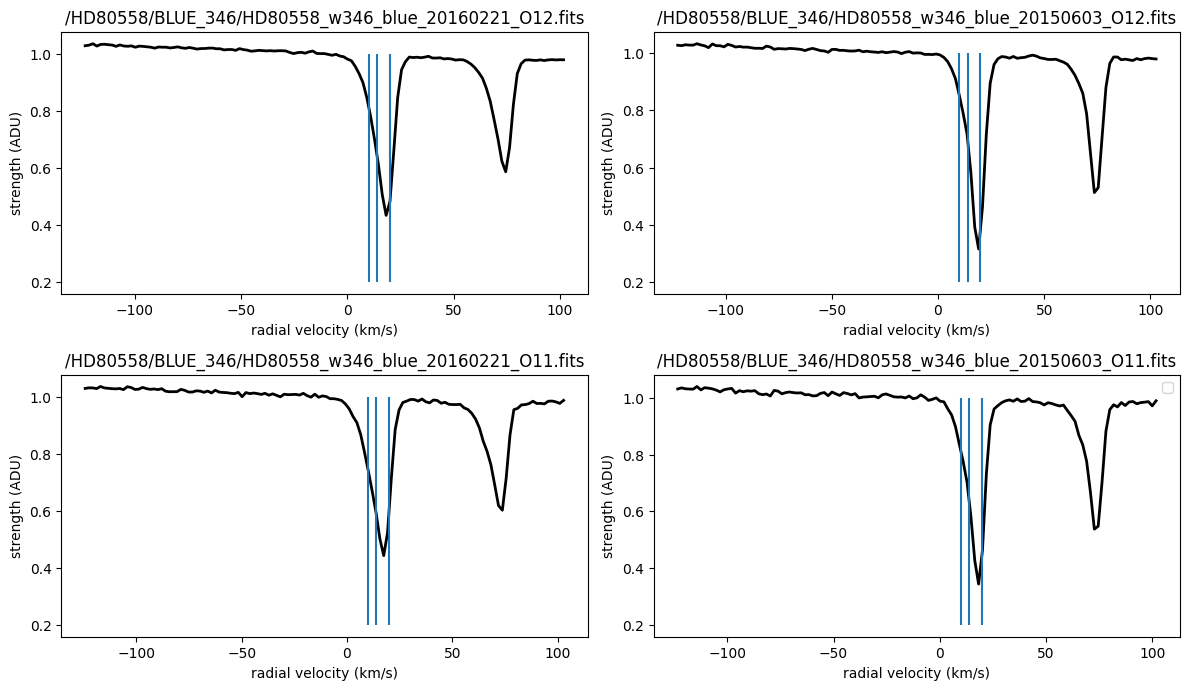

/HD80558/BLUE_346/HD80558_w346_blue_20160221_O12.fits
/HD80558/BLUE_346/HD80558_w346_blue_20150603_O12.fits
/HD80558/BLUE_346/HD80558_w346_blue_20160221_O11.fits
/HD80558/BLUE_346/HD80558_w346_blue_20150603_O11.fits


In [17]:
sightline = "HD 80558"
pythia = EdiblesOracle()
List_1 = pythia.getFilteredObsList(object=[sightline], MergedOnly=False, Wave=3302)
test_1 = List_1.values.tolist()
List_2 = pythia.getFilteredObsList(object=[sightline], MergedOnly=True, Wave=3302)
test_2 = List_2.values.tolist()
test = set(test_1) - set(test_2)
test = list(test)
# print(test)

# filename = test[6]

lambda0 = [3302.368, 3302.978]
ref_wave = 3302.368
cl_1 = 20
cl_2 = 14
cl_3 = 10
cl_4 = 3
# cl_5 = 12
# cl_5 = -7
# f = [0.005450, 0.005450]
# gamma = [1e8,1e8]
# b = [3.5, 3.5]
# N = [5e13/50, 5e13]
# map = [0, 1]
# v_rad = 20
# v_resolution = 3
# B_vary = [0]

l = len(test)
rows = l//2 + 1

# Create a figure and an array of subplots (3x3 grid)
fig, axs = plt.subplots(rows, 2, figsize=(12,10))#(12, 15))

# Flatten the 2D array of axes to easily index them in a single loop
axs = axs.flatten()

for i in range(len(test)):
    #++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
    # Define the wavelength range and fetch the spectrum
    wrange = [3301, 3303.5]
    sp = EdiblesSpectrum(test[i])
    sp.getSpectrum(xmin=wrange[0], xmax=wrange[1])
    wave = sp.bary_wave
    flux = sp.bary_flux

    # Filter the spectrum within the specified wavelength range
    idx = np.where((wave > wrange[0]) & (wave < wrange[1]))
    wave = wave[idx]
    flux = flux[idx]

    # Normalize the flux
    flux = flux / np.median(flux)
    #++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

    # Plot data on the corresponding subplot
    axs[i].plot(3*(10**5)*(wave-ref_wave)/ref_wave, flux, color='k', linewidth=2)
    axs[i].vlines(x=cl_1, ymin=0.2, ymax=1)
    axs[i].vlines(x=cl_2, ymin=0.2, ymax=1)
    axs[i].vlines(x=cl_3, ymin=0.2, ymax=1)
    # axs[i].vlines(x=cl_4, ymin=0.4, ymax=1)
    # axs[i].vlines(x=cl_5, ymin=0.4, ymax=1)


    # y = np.ones(len(wave))
    # axs[i].plot(wave, y)
    #++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

    # model = voigt_absorption_line_new(wavegrid=wave, f= f, lambda0=lambda0, gamma=gamma, 
    #                    b=b, B_vary=B_vary, N=N, v_rad=v_rad, v_resolution=v_resolution, map =[0,1])
    
    # axs[i].plot(wave, model)

    # Set title for each subplot
    axs[i].set_title(str(test[i]))

    # Set x and y labels for each subplot
    axs[i].set_xlabel('radial velocity (km/s)')
    axs[i].set_ylabel('strength (ADU)')

# Hide the unused subplots
for j in range(len(test), len(axs)):
    fig.delaxes(axs[j])
# Adjust the layout so titles and labels fit well
plt.tight_layout()
plt.legend()
# Show the plot
plt.show()   


for i in test:
    print(i)

# Na II

/Users/ayansahoo/Desktop/MITACS_2024_Canada/edibles/DR4
***Common Objects***
['HD 23466']
**Filtered File List**
11633    /HD23466/RED_564/HD23466_w564_redu_20180731_O5...
11660    /HD23466/RED_564/HD23466_w564_redu_20180731_O4...
11667    /HD23466/RED_564/HD23466_w564_n10_20180731_U.fits
Name: Filename, dtype: object
3
***Common Objects***
['HD 23466']
**Filtered File List**
11667    /HD23466/RED_564/HD23466_w564_n10_20180731_U.fits
Name: Filename, dtype: object
1


/var/folders/82/4_zfr0ld1js5_5zv4y2mzvs00000gn/T/ipykernel_38691/2706669103.py:83: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


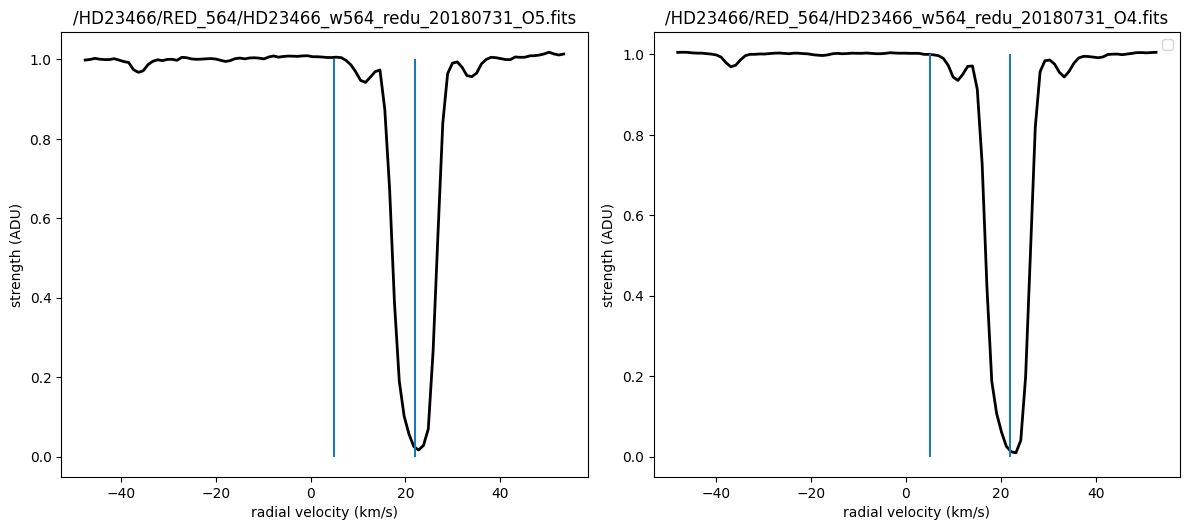

/HD23466/RED_564/HD23466_w564_redu_20180731_O5.fits
/HD23466/RED_564/HD23466_w564_redu_20180731_O4.fits


In [3]:
sightline = "HD 23466"
pythia = EdiblesOracle()
List_1 = pythia.getFilteredObsList(object=[sightline], MergedOnly=False, Wave=5892)
test_1 = List_1.values.tolist()
List_2 = pythia.getFilteredObsList(object=[sightline], MergedOnly=True, Wave=5892)
test_2 = List_2.values.tolist()
test = set(test_1) - set(test_2)
test = list(test)
# print(test)

# filename = test[6]

lambda0 = [5889.951, 5895.924]
ref_wave = 5889.951
cl_1 = 22
cl_2 = 5
# cl_3 = -38
# cl_4 = -24
# f = [0.005450, 0.005450]
# gamma = [1e8,1e8]
# b = [3.5, 3.5]
# N = [5e13/50, 5e13]
# map = [0, 1]
# v_rad = 20
# v_resolution = 3
# B_vary = [0]

l = len(test)
rows = l//2 + 1

# Create a figure and an array of subplots (3x3 grid)
fig, axs = plt.subplots(rows, 2, figsize=(12,10))#(12, 15))

# Flatten the 2D array of axes to easily index them in a single loop
axs = axs.flatten()

for i in range(len(test)):
    #++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
    # Define the wavelength range and fetch the spectrum
    wrange = [5889, 5891]
    sp = EdiblesSpectrum(test[i])
    sp.getSpectrum(xmin=wrange[0], xmax=wrange[1])
    wave = sp.bary_wave
    flux = sp.bary_flux

    # Filter the spectrum within the specified wavelength range
    idx = np.where((wave > wrange[0]) & (wave < wrange[1]))
    wave = wave[idx]
    flux = flux[idx]

    # Normalize the flux
    flux = flux / np.median(flux)
    #++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

    # Plot data on the corresponding subplot
    axs[i].plot(3*(10**5)*(wave-ref_wave)/ref_wave, flux, color='k', linewidth=2)
    axs[i].vlines(x=cl_1, ymin=0, ymax=1)
    axs[i].vlines(x=cl_2, ymin=0, ymax=1)
    # axs[i].vlines(x=cl_3, ymin=0, ymax=1)
    # axs[i].vlines(x=cl_4, ymin=0, ymax=1)

    # y = np.ones(len(wave))
    # axs[i].plot(wave, y)
    #++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

    # model = voigt_absorption_line_new(wavegrid=wave, f= f, lambda0=lambda0, gamma=gamma, 
    #                    b=b, B_vary=B_vary, N=N, v_rad=v_rad, v_resolution=v_resolution, map =[0,1])
    
    # axs[i].plot(wave, model)

    # Set title for each subplot
    axs[i].set_title(str(test[i]))

    # Set x and y labels for each subplot
    axs[i].set_xlabel('radial velocity (km/s)')
    axs[i].set_ylabel('strength (ADU)')

# Hide the unused subplots
for j in range(len(test), len(axs)):
    fig.delaxes(axs[j])
# Adjust the layout so titles and labels fit well
plt.tight_layout()
plt.legend()
# Show the plot
plt.show()   


for i in test:
    print(i)

# K (7664)

/Users/ayansahoo/Desktop/MITACS_2024_Canada/edibles/DR4
***Common Objects***
['HD 23466']
**Filtered File List**
11711     /HD23466/RED_860/HD23466_w860_n9_20180731_L.fits
11722    /HD23466/RED_860/HD23466_w860_redl_20180731_O1...
11723    /HD23466/RED_860/HD23466_w860_redl_20180731_O1...
Name: Filename, dtype: object
3
***Common Objects***
['HD 23466']
**Filtered File List**
11711    /HD23466/RED_860/HD23466_w860_n9_20180731_L.fits
Name: Filename, dtype: object
1


/var/folders/82/4_zfr0ld1js5_5zv4y2mzvs00000gn/T/ipykernel_38691/4142815123.py:87: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


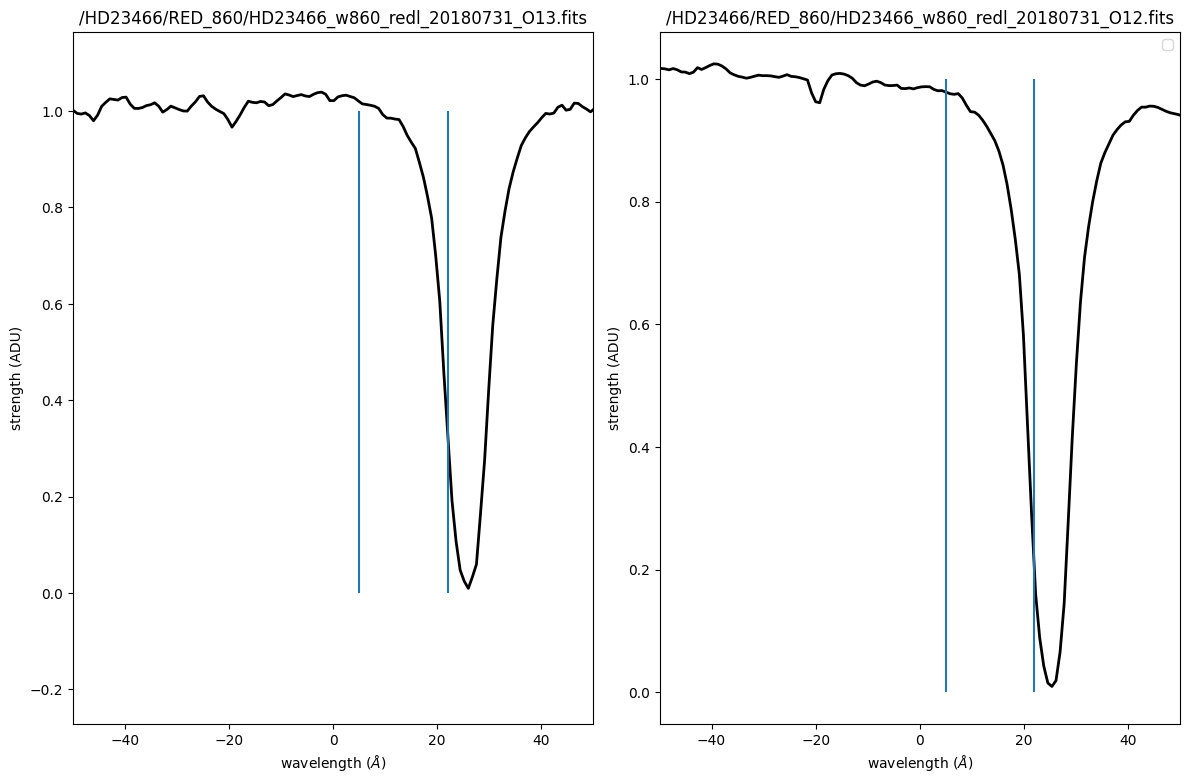

/HD23466/RED_860/HD23466_w860_redl_20180731_O13.fits
/HD23466/RED_860/HD23466_w860_redl_20180731_O12.fits


In [4]:
sightline = "HD 23466"
pythia = EdiblesOracle()
List_1 = pythia.getFilteredObsList(object=[sightline], MergedOnly=False, Wave=7665)
test_1 = List_1.values.tolist()
List_2 = pythia.getFilteredObsList(object=[sightline], MergedOnly=True, Wave=7665)
test_2 = List_2.values.tolist()
test = set(test_1) - set(test_2)
test = list(test)
# print(test)

# filename = test[6]

lambda0 = [7664.899]
ref_wave = 7664.899
cl_1 = 22
cl_2 = 5
# cl_3 = -38
# cl_4 = -24
# cl_5 = -10
# f = [0.005450, 0.005450]
# gamma = [1e8,1e8]
# b = [3.5, 3.5]
# N = [5e13/50, 5e13]
# map = [0, 1]
# v_rad = 20
# v_resolution = 3
# B_vary = [0]

l = len(test)
rows = l//2 + 1

# Create a figure and an array of subplots (3x3 grid)
fig, axs = plt.subplots(rows, 2, figsize=(12, 15))

# Flatten the 2D array of axes to easily index them in a single loop
axs = axs.flatten()

for i in range(len(test)):
    #++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
    # Define the wavelength range and fetch the spectrum
    wrange = [7661, 7670]
    
    sp = EdiblesSpectrum(test[i])
    sp.getSpectrum(xmin=wrange[0], xmax=wrange[1])
    wave = sp.bary_wave
    flux = sp.bary_flux

    # Filter the spectrum within the specified wavelength range
    idx = np.where((wave > wrange[0]) & (wave < wrange[1]))
    wave = wave[idx]
    flux = flux[idx]

    # Normalize the flux
    flux = flux / np.median(flux)
    #++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

    # Plot data on the corresponding subplot
    axs[i].plot(3*(10**5)*(wave-ref_wave)/ref_wave, flux, color='k', linewidth=2)
    axs[i].vlines(x=cl_1, ymin=0, ymax=1)
    axs[i].vlines(x=cl_2, ymin=0, ymax=1)
    # axs[i].vlines(x=cl_3, ymin=0, ymax=1)
    # axs[i].vlines(x=cl_4, ymin=0, ymax=1)
    # axs[i].vlines(x=cl_5, ymin=0, ymax=1)
    # y = np.ones(len(wave))
    # axs[i].plot(wave, y)
    #++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

    # model = voigt_absorption_line_new(wavegrid=wave, f= f, lambda0=lambda0, gamma=gamma, 
    #                    b=b, B_vary=B_vary, N=N, v_rad=v_rad, v_resolution=v_resolution, map =[0,1])
    
    # axs[i].plot(wave, model)

    # Set title for each subplot
    axs[i].set_title(str(test[i]))

    # Set x and y labels for each subplot
    axs[i].set_xlabel('wavelength ($\AA$)')
    axs[i].set_ylabel('strength (ADU)')

    axs[i].set_xlim(-50, 50)

# Hide the unused subplots
for j in range(len(test), len(axs)):
    fig.delaxes(axs[j])
# Adjust the layout so titles and labels fit well
plt.tight_layout()
plt.legend()
# Show the plot
plt.show()   


for i in test:
    print(i)

# K (7698)

/Users/ayansahoo/Desktop/MITACS_2024_Canada/edibles/DR4
***Common Objects***
['HD 80558']
**Filtered File List**
27136    /HD80558/RED_860/HD80558_w860_redl_20150630_O1...
27147    /HD80558/RED_860/HD80558_w860_redl_20160221_O1...
27155    /HD80558/RED_860/HD80558_w860_n13_20160221_L.fits
27159    /HD80558/RED_860/HD80558_w860_n20_20150630_L.fits
Name: Filename, dtype: object
4
***Common Objects***
['HD 80558']
**Filtered File List**
27155    /HD80558/RED_860/HD80558_w860_n13_20160221_L.fits
27159    /HD80558/RED_860/HD80558_w860_n20_20150630_L.fits
Name: Filename, dtype: object
2


/var/folders/82/4_zfr0ld1js5_5zv4y2mzvs00000gn/T/ipykernel_38691/2048984004.py:87: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


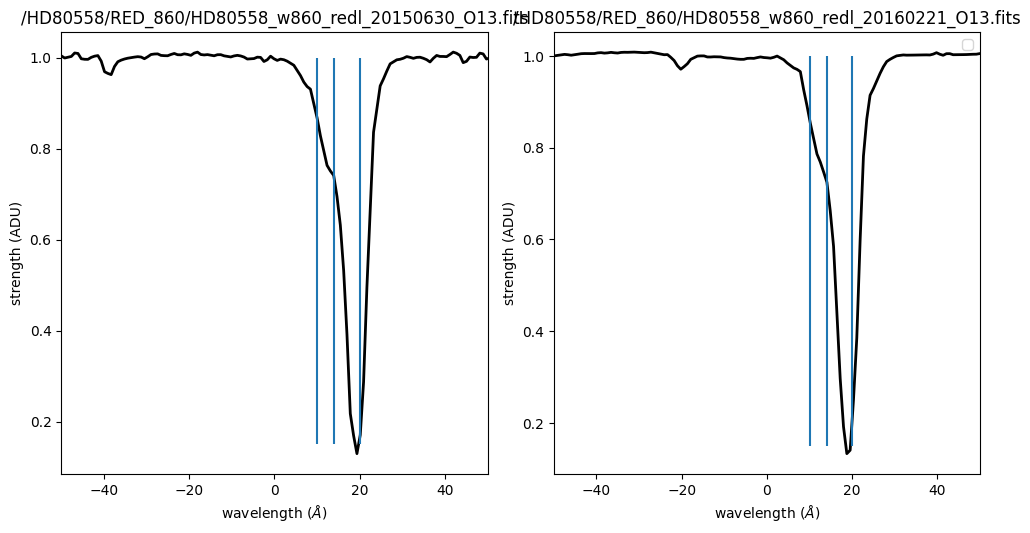

/HD80558/RED_860/HD80558_w860_redl_20150630_O13.fits
/HD80558/RED_860/HD80558_w860_redl_20160221_O13.fits


In [15]:
sightline = "HD 80558"
pythia = EdiblesOracle()
List_1 = pythia.getFilteredObsList(object=[sightline], MergedOnly=False, Wave=7698)
test_1 = List_1.values.tolist()
List_2 = pythia.getFilteredObsList(object=[sightline], MergedOnly=True, Wave=7698)
test_2 = List_2.values.tolist()
test = set(test_1) - set(test_2)
test = list(test)
# print(test)

# filename = test[6]

lambda0 = [7698.965]
ref_wave = 7698.965
cl_1 = 20
cl_2 = 14
cl_3 = 10
cl_4 = 3
# cl_5 = 5
# f = [0.005450, 0.005450]
# gamma = [1e8,1e8]
# b = [3.5, 3.5]
# N = [5e13/50, 5e13]
# map = [0, 1]
# v_rad = 20
# v_resolution = 3
# B_vary = [0]

l = len(test)
rows = l//2 + 1

# Create a figure and an array of subplots (3x3 grid)
fig, axs = plt.subplots(rows, 2, figsize=(10, 10))

# Flatten the 2D array of axes to easily index them in a single loop
axs = axs.flatten()

for i in range(len(test)):
    #++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
    # Define the wavelength range and fetch the spectrum
    wrange = [7697, 7701]
    
    sp = EdiblesSpectrum(test[i])
    sp.getSpectrum(xmin=wrange[0], xmax=wrange[1])
    wave = sp.bary_wave
    flux = sp.bary_flux

    # Filter the spectrum within the specified wavelength range
    idx = np.where((wave > wrange[0]) & (wave < wrange[1]))
    wave = wave[idx]
    flux = flux[idx]

    # Normalize the flux
    flux = flux / np.median(flux)
    #++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

    # Plot data on the corresponding subplot
    axs[i].plot(3*(10**5)*(wave-ref_wave)/ref_wave, flux, color='k', linewidth=2)
    axs[i].vlines(x=cl_1, ymin=0.15, ymax=1)
    axs[i].vlines(x=cl_2, ymin=0.15, ymax=1)
    axs[i].vlines(x=cl_3, ymin=0.15, ymax=1)
    # axs[i].vlines(x=cl_4, ymin=0.15, ymax=1)
    # axs[i].vlines(x=cl_5, ymin=0.1, ymax=1)
    # y = np.ones(len(wave))
    # axs[i].plot(wave, y)
    #++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++

    # model = voigt_absorption_line_new(wavegrid=wave, f= f, lambda0=lambda0, gamma=gamma, 
    #                    b=b, B_vary=B_vary, N=N, v_rad=v_rad, v_resolution=v_resolution, map =[0,1])
    
    # axs[i].plot(wave, model)

    # Set title for each subplot
    axs[i].set_title(str(test[i]))

    # Set x and y labels for each subplot
    axs[i].set_xlabel('wavelength ($\AA$)')
    axs[i].set_ylabel('strength (ADU)')

    axs[i].set_xlim(-50, 50)

# Hide the unused subplots
for j in range(len(test), len(axs)):
    fig.delaxes(axs[j])
# Adjust the layout so titles and labels fit well
plt.tight_layout()
plt.legend()
# Show the plot
plt.show()   


for i in test:
    print(i)